In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
data = pd.read_excel('../../data/data.xlsx', sheet_name='FactOrder')

In [5]:
data

,Order ID,Customer ID,Order Priority,Order Date,Market,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Returned,Row ID,Ship Date,Ship Mode,City,State,Country,Region
0,CA-2011-115812,BH-11710,Medium,"Thursday, June 9, 2011",US,FUR-FU-10001487,48.860001,7,0.0,14.169400,2.910000,False,31302,"Tuesday, June 14, 2011",Standard Class,Los Angeles,California,United States,West
1,CA-2011-115812,BH-11710,Medium,"Thursday, June 9, 2011",US,OFF-AR-10002833,7.280000,4,0.0,1.965600,0.490000,False,31303,"Tuesday, June 14, 2011",Standard Class,Los Angeles,California,United States,West
2,CA-2011-115812,BH-11710,Medium,"Thursday, June 9, 2011",US,OFF-AP-10002892,114.900002,5,0.0,34.470001,8.230000,False,31306,"Tuesday, June 14, 2011",Standard Class,Los Angeles,California,United States,West
3,CA-2013-101343,RA-19885,Medium,"Thursday, July 18, 2013",US,OFF-ST-10003479,77.879997,2,0.0,3.894000,4.310000,False,31339,"Tuesday, July 23, 2013",Standard Class,Los Angeles,California,United States,West
4,CA-2012-135545,KM-16720,Medium,"Saturday, November 24, 2012",US,TEC-AC-10004633,13.980000,2,0.0,6.151200,0.690000,False,31359,"Friday, November 30, 2012",Standard Class,Los Angeles,California,United States,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49665,CA-2011-123855,MC-18100,Medium,"Saturday, June 18, 2011",US,TEC-PH-10000215,139.800003,5,0.2,12.232500,13.800000,False,41061,"Thursday, June 23, 2011",Standard Class,Los Angeles,California,United States,West
49666,US-2013-103674,AP-10720,Medium,"Saturday, December 7, 2013",US,TEC-PH-10004080,271.959991,5,0.2,27.195999,19.230000,False,41270,"Wednesday, December 11, 2013",Standard Class,Los Angeles,California,United States,West
49667,US-2013-103674,AP-10720,Medium,"Saturday, December 7, 2013",US,TEC-PH-10002496,249.584000,2,0.2,31.198000,15.660000,False,41273,"Wednesday, December 11, 2013",Standard Class,Los Angeles,California,United States,West
49668,US-2013-103674,AP-10720,Medium,"Saturday, December 7, 2013",US,OFF-BI-10003727,13.376000,4,0.2,4.681600,0.840000,False,41275,"Wednesday, December 11, 2013",Standard Class,Los Angeles,California,United States,West


In [6]:
data.columns

Index(['Order ID', 'Customer ID', 'Order Priority', 'Order Date', 'Market',
       'Product ID', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Returned', 'Row ID', 'Ship Date', 'Ship Mode', 'City',
       'State', 'Country', 'Region'],
      dtype='str')

In [10]:
data["Discount Status"] = np.where(data["Discount"] > 0,"Discounted","Non-discounted")

In [12]:
descriptive = (
    data.groupby("Discount Status")["Quantity"].agg(
          n="count",
          mean="mean",
          median="median",
          std="std",
          min="min",
          Q1=lambda x: x.quantile(0.25),
          Q3=lambda x: x.quantile(0.75),
          max="max"))

descriptive["IQR"] = descriptive["Q3"] - descriptive["Q1"]

descriptive

,n,mean,median,std,min,Q1,Q3,max,IQR
Discount Status,,,,,,,,,
Discounted,21567,3.568507,3.0,2.258748,1,2.0,5.0,14,3.0
Non-discounted,28103,3.395794,3.0,2.284344,1,2.0,5.0,14,3.0


In [13]:
skewness = (
    data.groupby("Discount Status")["Quantity"]
      .skew()
      .rename("Skewness"))

descriptive = descriptive.join(skewness)

descriptive

,n,mean,median,std,min,Q1,Q3,max,IQR,Skewness
Discount Status,,,,,,,,,,
Discounted,21567,3.568507,3.0,2.258748,1,2.0,5.0,14,3.0,1.342942
Non-discounted,28103,3.395794,3.0,2.284344,1,2.0,5.0,14,3.0,1.384387


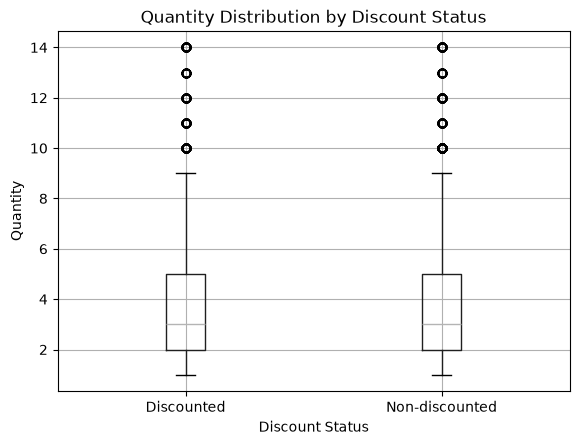

In [15]:
data.boxplot(
    column="Quantity",
    by="Discount Status")

plt.title("Quantity Distribution by Discount Status")
plt.suptitle("")
plt.xlabel("Discount Status")
plt.ylabel("Quantity")
plt.show()

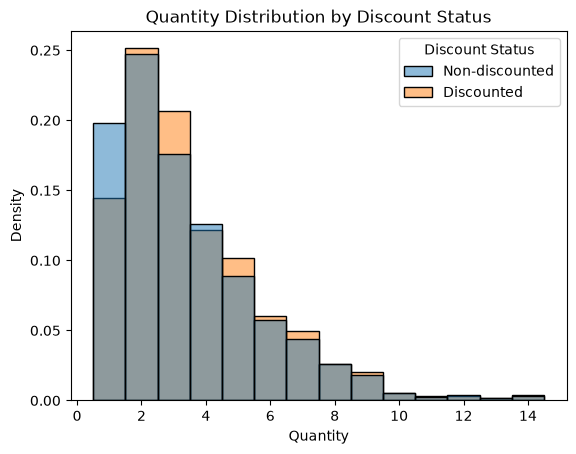

In [16]:
import seaborn as sns

sns.histplot(
    data=data,
    x="Quantity",
    hue="Discount Status",
    discrete=True,
    stat="density",
    common_norm=False,
    multiple="layer"
)

plt.title("Quantity Distribution by Discount Status")
plt.xlabel("Quantity")
plt.ylabel("Density")
plt.show()

In [17]:
discounted = data.loc[data["Discount Status"] == "Discounted", "Quantity"]

non_discounted = data.loc[data["Discount Status"] == "Non-discounted", "Quantity"]

In [19]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    discounted,
    non_discounted,
    alternative="two-sided")

print("U statistic:", u_stat)
print("p-value:", p_value)

U statistic: 320990669.5
p-value: 1.2366179467933793e-30


In [20]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: there is a statistically significant difference.")
else:
    print("Fail to reject H0: there is no statistically significant difference.")

Reject H0: there is a statistically significant difference.


In [21]:
n1 = len(discounted)
n2 = len(non_discounted)

rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print("Rank-biserial correlation:", rank_biserial)

Rank-biserial correlation: 0.05920490327263428


In [22]:
data["Year"] = pd.to_datetime(data["Order Date"]).dt.year

In [26]:
region_table = pd.crosstab(
    data["Region"],
    data["Discount Status"])

region_table

Discount Status,Discounted,Non-discounted
Region,,
Africa,1003,3450
Canada,0,376
Caribbean,914,764
Central,4732,5517
Central Asia,304,1744
EMEA,1509,3326
East,1392,1440
North,1564,3004
North Asia,259,2079


In [27]:
region_percent = pd.crosstab(
    data["Region"],
    data["Discount Status"],
    normalize="index") * 100

region_percent

Discount Status,Discounted,Non-discounted
Region,,
Africa,22.524141,77.475859
Canada,0.000000,100.000000
Caribbean,54.469607,45.530393
Central,46.170358,53.829642
Central Asia,14.843750,85.156250
EMEA,31.209928,68.790072
East,49.152542,50.847458
North,34.238179,65.761821
North Asia,11.077844,88.922156


In [28]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    region_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 8489.117879992042
Degrees of freedom: 12
p-value: 0.0


In [29]:
n = region_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(region_table.shape[0] - 1,
                     region_table.shape[1] - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.41341306947838913


In [30]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import itertools
import numpy as np
import pandas as pd

results = []

regions = data["Region"].dropna().unique()

for region1, region2 in itertools.combinations(regions, 2):

    sub1 = data[data["Region"] == region1]
    sub2 = data[data["Region"] == region2]

    success = np.array([
        (sub1["Discount Status"] == "Discounted").sum(),
        (sub2["Discount Status"] == "Discounted").sum()
    ])

    nobs = np.array([
        len(sub1),
        len(sub2)
    ])

    z_stat, p_value = proportions_ztest(
        count=success,
        nobs=nobs
    )

    results.append({
        "Region 1": region1,
        "Region 2": region2,
        "Discounted % 1": success[0] / nobs[0] * 100,
        "Discounted % 2": success[1] / nobs[1] * 100,
        "Difference (pp)": (
            success[0] / nobs[0] -
            success[1] / nobs[1]
        ) * 100,
        "z": z_stat,
        "p_value": p_value
    })

pairwise_region = pd.DataFrame(results)

In [32]:
reject, p_adjusted, _, _ = multipletests(
    pairwise_region["p_value"],
    method="fdr_bh"
)

pairwise_region["p_adjusted"] = p_adjusted
pairwise_region["Significant"] = reject

In [33]:
pairwise_region

,Region 1,Region 2,Discounted % 1,Discounted % 2,Difference (pp),z,p_value,p_adjusted,Significant
0,West,East,46.407280,49.152542,-2.745263,-2.128383,3.330534e-02,3.373787e-02,True
1,West,South,46.407280,40.986133,5.421147,5.065832,4.066212e-07,4.467106e-07,True
2,West,Central,46.407280,46.170358,0.236921,0.234300,8.147524e-01,8.147524e-01,False
3,West,Caribbean,46.407280,54.469607,-8.062327,-5.346792,8.952695e-08,9.975861e-08,True
4,West,North,46.407280,34.238179,12.169101,10.798162,3.511609e-27,4.722508e-27,True
...,...,...,...,...,...,...,...,...,...
73,Oceania,Canada,85.574993,0.000000,85.574993,37.604107,1.841845e-309,8.978996e-309,True
74,Oceania,EMEA,85.574993,31.209928,54.365065,49.096111,0.000000e+00,0.000000e+00,True
75,Africa,Canada,22.524141,0.000000,22.524141,10.338896,4.699204e-25,6.108965e-25,True
76,Africa,EMEA,22.524141,31.209928,-8.685787,-9.414523,4.752346e-21,5.978757e-21,True


In [34]:
pairwise_region.sort_values("p_adjusted")

,Region 1,Region 2,Discounted % 1,Discounted % 2,Difference (pp),z,p_value,p_adjusted,Significant
27,South,Southeast Asia,40.986133,88.430809,-47.444676,-43.962971,0.000000,0.000000,True
29,South,Oceania,40.986133,85.574993,-44.588860,-42.843687,0.000000,0.000000,True
59,North Asia,Oceania,11.077844,85.574993,-74.497149,-56.102763,0.000000,0.000000,True
57,North Asia,Southeast Asia,11.077844,88.430809,-77.352964,-56.919121,0.000000,0.000000,True
63,Southeast Asia,Central Asia,88.430809,14.843750,73.587059,52.703468,0.000000,0.000000,True
...,...,...,...,...,...,...,...,...,...
64,Southeast Asia,Oceania,88.430809,85.574993,2.855816,3.440147,0.000581,0.000613,True
56,North,EMEA,34.238179,31.209928,3.028251,3.128983,0.001754,0.001824,True
13,East,Central,49.152542,46.170358,2.982184,2.815229,0.004874,0.005003,True
0,West,East,46.407280,49.152542,-2.745263,-2.128383,0.033305,0.033738,True


In [37]:
year_table = pd.crosstab(
    data["Year"],
    data["Discount Status"]
)

year_table

Discount Status,Discounted,Non-discounted
Year,,
2011,3902,4928
2012,4633,6018
2013,5731,7695
2014,7301,9462


In [35]:
year_percent = pd.crosstab(
    data["Year"],
    data["Discount Status"],
    normalize="index"
) * 100

year_percent

Discount Status,Discounted,Non-discounted
Year,,
2011,44.190260,55.809740
2012,43.498263,56.501737
2013,42.685833,57.314167
2014,43.554256,56.445744


In [38]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    year_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 5.227656410699183
Degrees of freedom: 3
p-value: 0.15586614179864655


In [39]:
n = year_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            year_table.shape[0] - 1,
            year_table.shape[1] - 1
        )
    )
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.010259033261120267


In [40]:
market_table = pd.crosstab(
    data["Market"],
    data["Discount Status"]
)

market_table

Discount Status,Discounted,Non-discounted
Market,,
APAC,6314,4688
Africa,1003,3450
Canada,0,376
EMEA,1509,3326
EU,3385,5442
LATAM,4187,6042
US,5169,4779


In [41]:
market_percent = pd.crosstab(
    data["Market"],
    data["Discount Status"],
    normalize="index"
) * 100

market_percent

Discount Status,Discounted,Non-discounted
Market,,
APAC,57.389566,42.610434
Africa,22.524141,77.475859
Canada,0.000000,100.000000
EMEA,31.209928,68.790072
EU,38.348250,61.651750
LATAM,40.932642,59.067358
US,51.960193,48.039807


In [42]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    market_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 2660.86181566693
Degrees of freedom: 6
p-value: 0.0


In [43]:
n = market_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            market_table.shape[0] - 1,
            market_table.shape[1] - 1
        )
    )
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.23145367488379223


In [44]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import itertools
import numpy as np
import pandas as pd

results = []

markets = data["Market"].dropna().unique()

for market1, market2 in itertools.combinations(markets, 2):

    sub1 = data[data["Market"] == market1]
    sub2 = data[data["Market"] == market2]

    success = np.array([
        (sub1["Discount Status"] == "Discounted").sum(),
        (sub2["Discount Status"] == "Discounted").sum()
    ])

    nobs = np.array([
        len(sub1),
        len(sub2)
    ])

    z_stat, p_value = proportions_ztest(
        count=success,
        nobs=nobs
    )

    prop1 = success[0] / nobs[0]
    prop2 = success[1] / nobs[1]

    results.append({
        "Market 1": market1,
        "Market 2": market2,
        "Discounted % 1": prop1 * 100,
        "Discounted % 2": prop2 * 100,
        "Difference (pp)": (prop1 - prop2) * 100,
        "z": z_stat,
        "p_value": p_value
    })

pairwise_market = pd.DataFrame(results)

In [45]:
reject, p_adjusted, _, _ = multipletests(
    pairwise_market["p_value"],
    method="fdr_bh"
)

pairwise_market["p_adjusted"] = p_adjusted
pairwise_market["Significant"] = reject

pairwise_market.sort_values("p_adjusted")

,Market 1,Market 2,Discounted % 1,Discounted % 2,Difference (pp),z,p_value,p_adjusted,Significant
15,APAC,Africa,57.389566,22.524141,34.865425,39.315722,0.000000e+00,0.000000e+00,True
3,US,Africa,51.960193,22.524141,29.436052,32.990100,1.126355e-238,1.182673e-237,True
17,APAC,EMEA,57.389566,31.209928,26.179638,30.347493,2.711321e-202,1.897925e-201,True
11,EU,APAC,38.348250,57.389566,-19.041316,-26.657631,1.459907e-156,7.664510e-156,True
7,LATAM,APAC,40.932642,57.389566,-16.456923,-23.964650,6.501203e-127,2.730505e-126,True
5,US,EMEA,51.960193,31.209928,20.750265,23.783258,4.977426e-125,1.742099e-124,True
16,APAC,Canada,57.389566,0.000000,57.389566,22.018945,1.896269e-107,5.688807e-107,True
8,LATAM,Africa,40.932642,22.524141,18.408501,21.448229,4.743707e-102,1.245223e-101,True
4,US,Canada,51.960193,0.000000,51.960193,19.780577,4.376510e-87,1.021186e-86,True
1,US,EU,51.960193,38.348250,13.611943,18.691891,5.763357e-78,1.210305e-77,True


In [47]:
returned_table = pd.crosstab(
    data["Returned"],
    data["Discount Status"]
)

returned_table

Discount Status,Discounted,Non-discounted
Returned,,
False,20353,26337
True,1214,1766


In [48]:
returned_percent = pd.crosstab(
    data["Returned"],
    data["Discount Status"],
    normalize="index"
) * 100

returned_percent

Discount Status,Discounted,Non-discounted
Returned,,
False,43.591776,56.408224
True,40.738255,59.261745


In [49]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    returned_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 9.168611852878355
Degrees of freedom: 1
p-value: 0.002462012451887669


In [50]:
discounted_data = data[data["Discount"] > 0].copy()

In [51]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    discounted_data["Discount"],
    discounted_data["Quantity"]
)

print("Spearman's rho:", rho)
print("p-value:", p_value)

Spearman's rho: -0.1375836970411763
p-value: 1.270943118878198e-91


In [52]:
import numpy as np
from scipy.stats import spearmanr

discounted_data = data[data["Discount"] > 0].copy()

x = discounted_data["Discount"].to_numpy()
y = discounted_data["Quantity"].to_numpy()

observed_rho, p_value = spearmanr(x, y)

rng = np.random.default_rng(42)

n_bootstrap = 5000
bootstrap_rhos = np.empty(n_bootstrap)

n = len(x)

for i in range(n_bootstrap):
    indices = rng.integers(0, n, n)
    
    bootstrap_rhos[i] = spearmanr(
        x[indices],
        y[indices]
    ).statistic

ci_lower = np.percentile(bootstrap_rhos, 2.5)
ci_upper = np.percentile(bootstrap_rhos, 97.5)

print("Spearman's rho:", observed_rho)
print("p-value:", p_value)
print("95% CI:", (ci_lower, ci_upper))

Spearman's rho: -0.1375836970411763
p-value: 1.270943118878198e-91
95% CI: (np.float64(-0.1508038241478138), np.float64(-0.12354646478971289))
